In [1]:
import os
import torch

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

import warnings
import yaml

warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from matplotlib.image import imread
from scipy import sparse
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [2]:
String = 'H'

patho_anno = pd.read_csv(f"../../data/BreastCancer/her2st-master/data/ST-pat/lbl/{String}1_labeled_coordinates.tsv", index_col=0, sep='\t')


adata_st_list_raw = []

for i in range(1, 4):
    # st_count = pd.read_csv("./data/HER2-positive/count-matrices/E%d.tsv.gz" % i, index_col=0, sep='\t')
    # st_meta = pd.read_csv("./data/HER2-positive/spot-selections/E%d_selection.tsv.gz" % i, sep='\t')
    st_count = pd.read_csv(f"../../data/BreastCancer/her2st-master/data/ST-cnts/{String}{i}.tsv.gz", index_col=0, sep='\t')
    st_meta = pd.read_csv(f"../../data/BreastCancer/her2st-master/data/ST-spotfiles/{String}{i}_selection.tsv", sep='\t')
    st_meta.index = [str(st_meta['x'][i]) + 'x' + str(st_meta['y'][i]) for i in range(st_meta.shape[0])]
    st_meta = st_meta.loc[st_count.index]
    
    adata_st_i = ad.AnnData(X=st_count.values)
    adata_st_i.obs.index = st_count.index
    adata_st_i.obs = st_meta
    adata_st_i.var.index = st_count.columns
    
    img = imread(f'../../data/BreastCancer/her2st-master/data/ST-imgs/{String}/{String}{i}.jpg')
    library_id = 'st'
    adata_st_i.uns["spatial"] = dict()
    adata_st_i.uns["spatial"][library_id] = dict()
    adata_st_i.uns["spatial"][library_id]['images'] = dict()
    adata_st_i.uns["spatial"][library_id]['images']['hires'] = img
    adata_st_i.uns["spatial"][library_id]['images']['lowres'] = img
    adata_st_i.uns["spatial"][library_id]['scalefactors'] = {'spot_diameter_fullres': 100,
                                                             'tissue_hires_scalef': 1.0,
                                                             'fiducial_diameter_fullres': 100,
                                                             'tissue_lowres_scalef': 1.0}
    
    adata_st_i.obsm['spatial'] = np.concatenate((np.array(st_meta["pixel_x"]).reshape(-1,1),
                                                 np.array(st_meta["pixel_y"]).reshape(-1,1)), axis=1)

    adata_st_i.obsm['loc_use'] = np.concatenate((np.array(st_meta["x"]).reshape(-1,1),
                                                 np.array(st_meta["y"]).reshape(-1,1)), axis=1)
    adata_st_i.obs['array_row'] = adata_st_i.obs["x"].values
    adata_st_i.obs['array_col'] = adata_st_i.obs["y"].values
    adata_st_i.obs['st_sample'] = String + str(i)

    if i == 1:
        adata_st_i.obs['annotation'] = None
        for idx in adata_st_i.obs.index:
            adata_st_i.obs['annotation'].loc[idx] = patho_anno[(patho_anno["x"] == adata_st_i[idx].obs["new_x"].values[0]) &
                                                               (patho_anno["y"] == adata_st_i[idx].obs["new_y"].values[0])]['label'].values[0]
    else:
        adata_st_i.obs['annotation'] = "Unknown"
    
    print(f'Slice {String}{i} spots:' + str(len(adata_st_i.obs)))

    adata_st_list_raw.append(adata_st_i)

Slice H1 spots:613
Slice H2 spots:603
Slice H3 spots:510


In [3]:
slice_use = []
for i in range(1,4):
    slice_id = String + str(i)
    slice_use.append(slice_id)
slice_use

['H1', 'H2', 'H3']

In [4]:
import STG3Net as MODEL

def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping


def get_data(proj_list, config):
    global graph_dict
    result, mapping = mapping2int(proj_list)
    adata = None
    for i, proj_name in enumerate(slice_use):
        adata_tmp = adata_st_list_raw[i]
        adata_tmp.obs['batch_name'] = adata_tmp.obs['st_sample']
        adata_tmp.obs['slice_id'] = mapping[proj_name]
        # adata_tmp = sc.read_visium(data_root / proj_name, count_file=proj_name + "_filtered_feature_bc_matrix.h5")
        # adata_tmp.var_names_make_unique()
        # 
        # adata_tmp.obs['batch_name'] = proj_name
        # adata_tmp.obs['slice_id'] = mapping[proj_name]
        # 
        # ##### Load layer_guess label, if have
        # truth_path = "../../data/DLPFC/" + proj_name + '/' + 'manual_annotations.txt'
        # Ann_df = pd.read_csv(truth_path, sep='\t', header=None, index_col=0)
        # Ann_df.columns = ['Ground Truth']
        # adata_tmp.obs['layer_guess'] = Ann_df.loc[adata_tmp.obs_names, 'Ground Truth']
        # adata_tmp = adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]

        graph_dict_tmp = MODEL.graph_construction(adata_tmp, config['k_cutoff'])
        if adata is None:
            adata = adata_tmp
            graph_dict = graph_dict_tmp
            name = proj_name
            adata.obs['proj_name'] = proj_name
        else:
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names]
            adata_tmp = adata_tmp[:, var_names]
            adata_tmp.obs['proj_name'] = proj_name

            adata = adata.concatenate(adata_tmp)
            graph_dict = MODEL.combine_graph_dict(graph_dict, graph_dict_tmp)
            name = name + '_' + proj_name

    adata.layers['count'] = adata.X
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['top_genes'])
    adata = adata[:, adata.var['highly_variable'] == True]
    sc.pp.scale(adata)
    
    from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
    adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
    adata.obsm['X_pca'] = adata_X
    return adata, graph_dict

In [5]:
with open('Config/Config_DLPFC.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

proj_list = slice_use
num_cluster = 6


adata, graph_dict = get_data(proj_list, config['data'])

In [6]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = MODEL.G3net(adata, graph_dict=graph_dict, device=device, config=config, num_cluster=num_cluster)

In [7]:
net.train(verbose=1)

Epoch 495 total loss=0.729 recon loss=0.926 tri loss=0.000 disc loss=0.809:  50%|████▉     | 498/1000 [00:17<00:16, 30.87it/s]R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
Processing datasets H1 have 9369 nodes or edges
Processing datasets H2 have 7371 nodes or edges


Epoch 500 total loss=1.514 recon loss=0.919 tri loss=0.793 disc loss=0.778:  50%|█████     | 502/1000 [00:21<02:29,  3.33it/s]

Processing datasets H3 have 4661 nodes or edges


Epoch 545 total loss=1.067 recon loss=0.981 tri loss=0.278 disc loss=1.030:  55%|█████▍    | 548/1000 [00:22<00:16, 28.24it/s]

...

fitting ...
  |======================================================================| 100%
Processing datasets H1 have 11683 nodes or edges
Processing datasets H2 have 10480 nodes or edges


Epoch 950 total loss=1.114 recon loss=0.962 tri loss=0.336 disc loss=1.052:  95%|█████████▌| 953/1000 [01:00<00:12,  3.68it/s]

Processing datasets H3 have 8662 nodes or edges


Epoch 995 total loss=1.023 recon loss=0.966 tri loss=0.242 disc loss=1.052: 100%|█████████▉| 995/1000 [01:02<00:00, 15.97it/s]

Stop trainning because of loss convergence


In [8]:
enc_rep, recon = net.process()
enc_rep = enc_rep.data.cpu().numpy()
recon = recon.data.cpu().numpy()
adata.obsm['latent'] = enc_rep
adata.obsm['recon'] = recon
print(adata)

AnnData object with n_obs × n_vars = 1726 × 2000
    obs: 'x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y', 'selected', 'array_row', 'array_col', 'st_sample', 'annotation', 'batch_name', 'slice_id', 'proj_name', 'batch', 'Tmp_domain'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'loc_use', 'X_pca', 'latent', 'recon'
    layers: 'count'


In [9]:
adata = net.clustering(adata, num_cluster=num_cluster, used_obsm='latent', key_added_pred='mclust', method='mclust', random_seed=666)

fitting ...
  |======================================================================| 100%


In [10]:
sub_adata = adata[adata.obs['batch_name'] == String+str('1')]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
print(f"total AMI:{AMI}")
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
print(f"total COM:{COM}")
V =  2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total ARI:0.3058742797900456
total NMI:0.43444726672797634
total AMI:0.4263674150958602
total HOM:0.42975263675123443
total COM:0.4392455980831996
total V:0.43444726672797634


2.5301995761270017


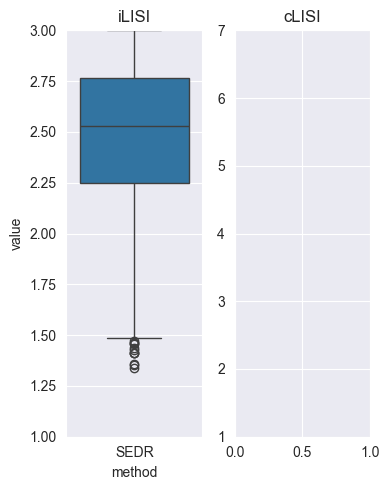

In [11]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata.obsm['latent'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
#cLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
#sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
#print(np.median(cLISI))

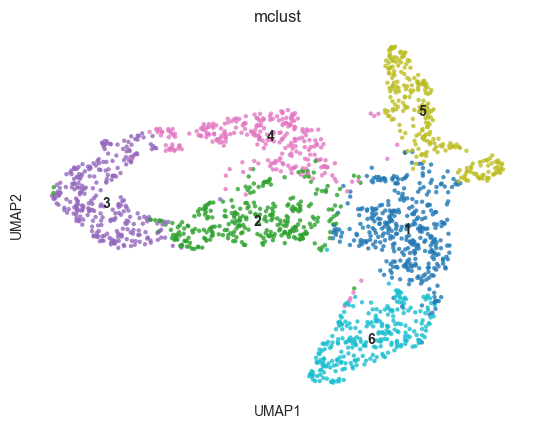

In [12]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色
import scanpy as sc
import matplotlib.pyplot as plt

sc.pp.neighbors(adata, use_rep='latent', metric='cosine', n_neighbors=15)  # 可调整 n_neighbors
sc.tl.umap(adata)  # 调整 min_dist 参数优化聚类

sc.pl.umap(
    adata,
    color=['mclust'],
    size=40,  # 调整点大小
    alpha=0.8,  # 调整透明度
    palette='tab10',  # 自定义调色板
    legend_loc='on data'
)

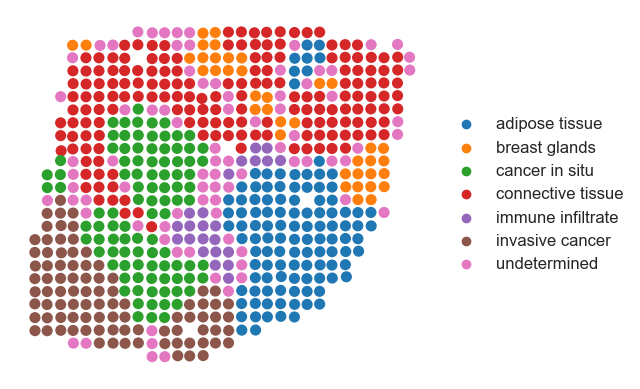

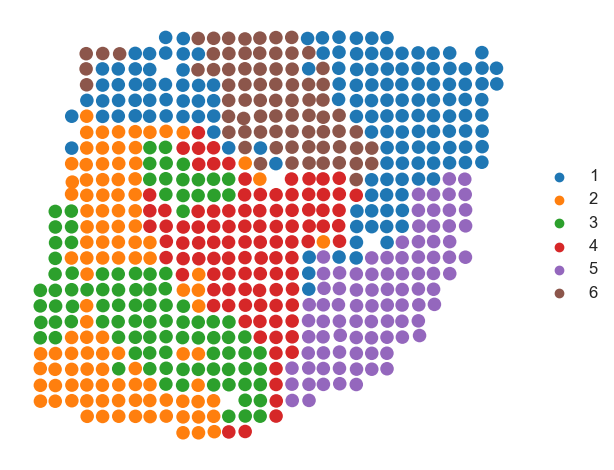

In [13]:
import matplotlib.pyplot as plt


adata_tmp_A1 = adata[adata.obs['batch_name'] == String+str(1)]
adata_tmp_A1.uns = adata_st_list_raw[1].uns

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['annotation'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

sc.pl.spatial(adata_tmp_A1, img_key='hires', color=['mclust'], title=[''],
              legend_loc='right margin', legend_fontsize=12, show=False, frameon=False, spot_size=250)

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='annotation',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

# sc.pl.scatter(adata_tmp_A1, 
#               x='x',  # 这里假设你的空间坐标 x 存储在 'spatial_x' 列中
#               y='y',  # 这里假设你的空间坐标 y 存储在 'spatial_y' 列中
#               color='mclust',  # 设置颜色为注释（annotation）
#               title='',  # 设置标题为空
#               legend_loc='right margin',  # 设置图例位置
#               legend_fontsize=12,  # 设置图例字体大小
#               show=False,  # 不自动显示图形
#               frameon=False)  # 不显示边框

plt.tight_layout()

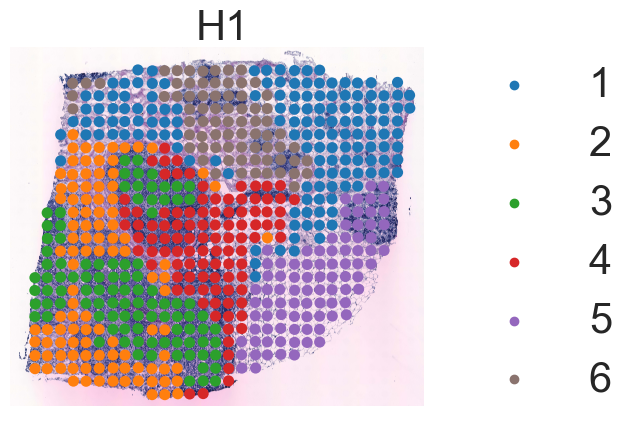

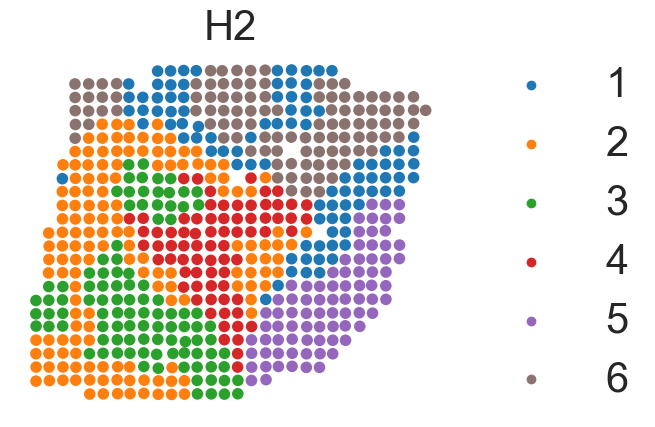

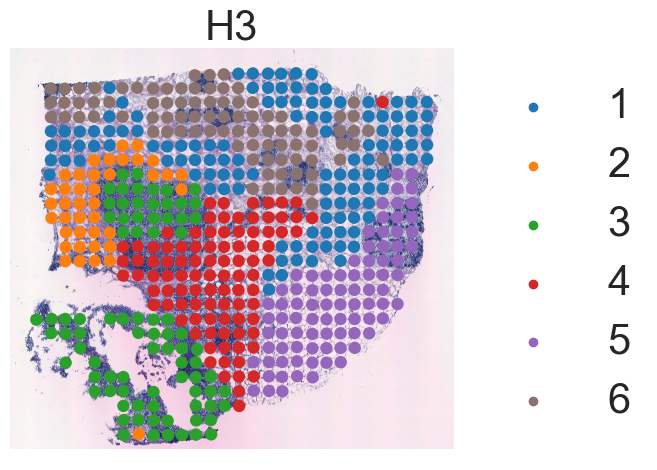

In [14]:
import matplotlib.pyplot as plt

cluster_colors = {
    1: '#1f77b4',  # Cluster 0 -> 蓝色
    2: '#ff7f0e',  # Cluster 1 -> 橙色
    3: '#2ca02c',  # Cluster 2 -> 绿色
    4: '#d62728',  # Cluster 3 -> 红色
    5: '#9467bd',  # Cluster 4 -> 紫色
    6: '#8a736e'   # Cluster 5 -> 
}


for i, slice_name in enumerate(slice_use):
    adata_tmp = adata[adata.obs['batch_name'] == String+str(i+1)]
    adata_tmp.uns = adata_st_list_raw[i].uns
    sc.pl.spatial(adata_tmp, img_key='hires', color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=30, show=False, frameon=False, spot_size=250,
                  palette=cluster_colors)
    plt.title(f'{slice_name}', fontsize=30)
    plt.savefig(f"D:\\njy\MutipelSliceSTD\MS\论文图表设计\Figure8_BC\FS12\\{String}\STG3Net_{i+1}.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()